
# SAE - Analyse Yelp avec DistilBERT (Déjà Fine-Tuné)

Ce notebook utilise un modèle **DistilBERT déjà fine-tuné** pour réaliser
une classification de polarité des avis Yelp.

La méthode utilisée est celle du **model + tokeniser**. 

Modèle utilisé :
`distilbert-base-uncased-finetuned-sst-2-english`


## I) Pré Fine-uné

### 1. Installation des dépendances

In [ ]:

!pip install transformers torch pandas scikit-learn tf-keras huggingface_hub[hf_xet]


### 2. Import

In [38]:
import json
import pandas as pd
import torch
from torch.nn.functional import softmax
from sklearn.metrics import classification_report, f1_score, accuracy_score, precision_score, confusion_matrix
from transformers import pipeline, DistilBertTokenizerFast, DistilBertForSequenceClassification

### 3. Chargement fichiers

In [29]:
reviews = [json.loads(line) for line in open("../data/raw/yelp_academic_reviews4students.jsonl", "r", encoding="utf-8")]
df = pd.DataFrame(reviews)[["text", "stars"]]
df.head()

,text,stars
0,Went for lunch and found that my burger was me...,2
1,I needed a new tires for my wife's car. They h...,5
2,Jim Woltman who works at Goleta Honda is 5 sta...,5
3,Been here a few times to get some shrimp. The...,4
4,This is one fantastic place to eat whether you...,5


In [46]:
# Préparation des données
texts = df["text"][:600].tolist()
labels = df["stars"][:600].tolist()

def polarity_label(stars):
    if stars < 3:
        return 0
    elif stars > 3:
        return 1
    else:
        return 2
    
labels = [polarity_label(star) for star in labels]

print(f"Nombre de reviews: {len(texts)}")
print(f"Distribution des labels: {pd.Series(labels).value_counts().to_dict()}")

Nombre de reviews: 600
Distribution des labels: {1: 395, 0: 136, 2: 69}


### 4. Modèle

In [33]:
model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name)

### 5. Prédictions

In [47]:
# Faire les prédictions
predictions = []
for text in texts:
    inputs = tokenizer(text[:512], return_tensors="pt", truncation=True)
    outputs = model(**inputs)
    logits = outputs.logits
    probs = softmax(logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()
    predictions.append(pred)

print(f"Prédictions terminées: {len(predictions)} reviews")

Prédictions terminées: 600 reviews


### 6. Métriques de précision

In [48]:
# Filtrer les neutres et calculer les métriques
valid_indices = [i for i, label in enumerate(labels) if label != 2]
predictions_binary = [predictions[i] for i in valid_indices]
labels_binary = [labels[i] for i in valid_indices]

# Calcul des métriques
acc = accuracy_score(labels_binary, predictions_binary)
prec = precision_score(labels_binary, predictions_binary, zero_division=0)
f1_val = f1_score(labels_binary, predictions_binary, zero_division=0)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"F1-Score:  {f1_val:.4f}")

Accuracy:  0.9058
Precision: 0.9625
F1-Score:  0.9349


Matrice de confusion:
[[122  14]
 [ 36 359]]


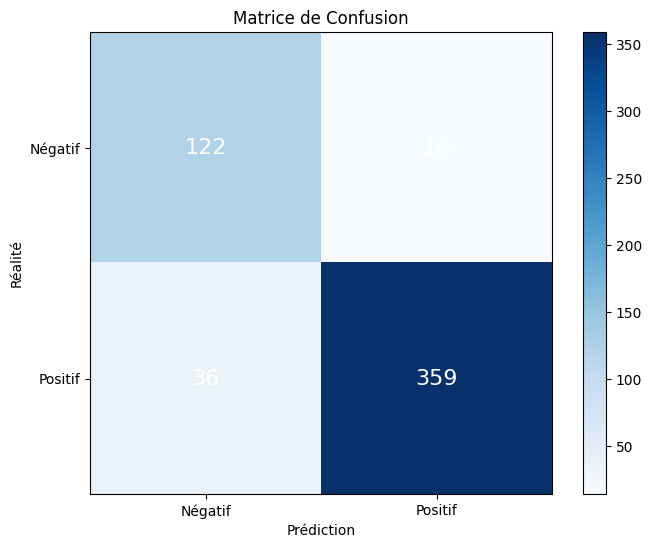

In [49]:
# Matrice de confusion
import matplotlib.pyplot as plt

cm = confusion_matrix(labels_binary, predictions_binary)
print("Matrice de confusion:")
print(cm)

# Visualisation
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title('Matrice de Confusion')
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.xticks([0, 1], ['Négatif', 'Positif'])
plt.yticks([0, 1], ['Négatif', 'Positif'])

# Ajouter les valeurs dans les cellules
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white', fontsize=16)

plt.colorbar()
plt.show()